In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt

In [2]:
fp32_path = "../../../full_precision/memorization/experiments"

# Attack mem ep

In [3]:
expath = '../attack_mem_ep'
# results dataset
df = pd.read_parquet(os.path.join(expath,'attack_mem_ep.parquet'))

# attach also fp32
df_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_mem_ep/attack_mem_ep.parquet")) [['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
       '15b_ep0', '15b_ep0_em', '15b_ep0_bleu', '15b_ep0_meteor',
       '15b_ep0_rougeL', '15b_ep1', '15b_ep1_em', '15b_ep1_bleu',
       '15b_ep1_meteor', '15b_ep1_rougeL', '15b_ep2', '15b_ep2_em',
       '15b_ep2_bleu', '15b_ep2_meteor', '15b_ep2_rougeL', '15b_ep3',
       '15b_ep3_em', '15b_ep3_bleu', '15b_ep3_meteor', '15b_ep3_rougeL']]

merged_df = pd.merge(df, df_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')


## fp32

In [4]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for ep in eps:
        column_name = f'15b_{ep}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

ep_fp32_absolute = pd.DataFrame(mean_data, index=eps)
ep_fp32_absolute

,em,bleu,meteor,rougeL
ep0,0.300,57.590960,0.630527,0.624876
ep1,0.549,75.689394,0.780136,0.782796
ep2,0.567,76.090178,0.783977,0.783531
ep3,0.609,77.444160,0.801378,0.796632


In [5]:
# With the baseline
first = ep_fp32_absolute.iloc[0]

ep_fp32_baseline = ep_fp32_absolute.subtract(first)
ep_fp32_baseline

,em,bleu,meteor,rougeL
ep0,0.000,0.000000,0.000000,0.000000
ep1,0.249,18.098435,0.149609,0.157920
ep2,0.267,18.499219,0.153450,0.158654
ep3,0.309,19.853200,0.170851,0.171755


### bf16

In [6]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for ep in eps:
        column_name = f'bf16_{ep}_{metric}'
        mean_value = df[column_name].mean()
        mean_data[metric].append(mean_value)

ep_bf16_absolute = pd.DataFrame(mean_data, index=eps)
ep_bf16_absolute

,em,bleu,meteor,rougeL
ep0,0.302,57.614924,0.628937,0.624452
ep1,0.550,75.717031,0.780031,0.782793
ep2,0.571,76.069976,0.784100,0.782830
ep3,0.610,77.305064,0.800632,0.795634


In [7]:
# With the baseline
first = ep_bf16_absolute.iloc[0]

ep_bf16_baseline = ep_bf16_absolute.subtract(first)
ep_bf16_baseline

,em,bleu,meteor,rougeL
ep0,0.000,0.000000,0.000000,0.000000
ep1,0.248,18.102107,0.151093,0.158341
ep2,0.269,18.455052,0.155162,0.158378
ep3,0.308,19.690140,0.171695,0.171181


## int8

In [8]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for ep in eps:
        column_name = f'i8_{ep}_{metric}'
        mean_value = df[column_name].mean()
        mean_data[metric].append(mean_value)

ep_i8_absolute = pd.DataFrame(mean_data, index=eps)
ep_i8_absolute

,em,bleu,meteor,rougeL
ep0,0.297,57.121291,0.628467,0.620365
ep1,0.540,75.558972,0.780072,0.781780
ep2,0.563,75.850500,0.781918,0.781618
ep3,0.610,77.380866,0.801665,0.796619


In [9]:
# With the baseline
first = ep_i8_absolute.iloc[0]

ep_i8_baseline = ep_i8_absolute.subtract(first)
ep_i8_baseline

,em,bleu,meteor,rougeL
ep0,0.000,0.000000,0.000000,0.000000
ep1,0.243,18.437681,0.151605,0.161415
ep2,0.266,18.729209,0.153452,0.161253
ep3,0.313,20.259575,0.173198,0.176254


## i4

In [10]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for ep in eps:
        column_name = f'i4_{ep}_{metric}'
        mean_value = df[column_name].mean()
        mean_data[metric].append(mean_value)

ep_i4_absolute = pd.DataFrame(mean_data, index=eps)
ep_i4_absolute

,em,bleu,meteor,rougeL
ep0,0.248,53.988420,0.605747,0.596535
ep1,0.522,74.691274,0.767346,0.773100
ep2,0.550,75.522919,0.781693,0.779965
ep3,0.583,76.788414,0.795136,0.790262


In [11]:
# With the baseline
first = ep_i4_absolute.iloc[0]

ep_i4_baseline = ep_i4_absolute.subtract(first)
ep_i4_baseline

,em,bleu,meteor,rougeL
ep0,0.000,0.000000,0.000000,0.000000
ep1,0.274,20.702854,0.161599,0.176565
ep2,0.302,21.534500,0.175947,0.183430
ep3,0.335,22.799994,0.189390,0.193727


## Visuals


In [12]:
df_ep_mem_plot = pd.DataFrame({ 'fp32': ep_fp32_baseline['em'],
                                'bf16': ep_bf16_baseline['em'],
                               'i8': ep_i8_baseline['em'],
                               'i4': ep_i4_baseline['em']})
df_ep_mem_plot

,fp32,bf16,i8,i4
ep0,0.000,0.000,0.000,0.000
ep1,0.249,0.248,0.243,0.274
ep2,0.267,0.269,0.266,0.302
ep3,0.309,0.308,0.313,0.335


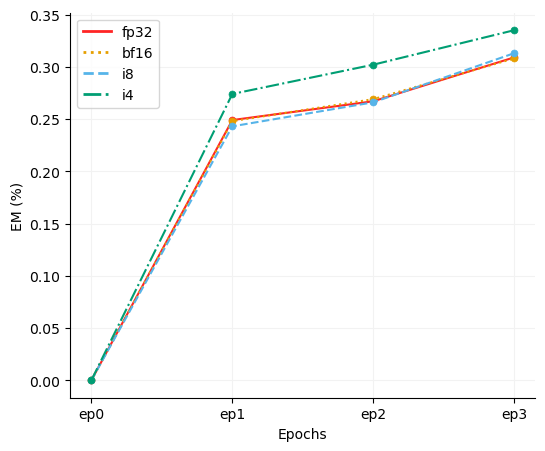

In [13]:
from matplotlib.lines import Line2D
from cycler import cycler

legend_elements = [Line2D([0], [0], lw=2, label='fp32', color='#FF2525', linestyle='-'),
                    Line2D([0], [0], lw=2, label='bf16', color='#E69F00', linestyle=':'),
                   Line2D([0], [0], lw=2, label='i8', color='#56B4E9', linestyle='--'),
                   Line2D([0], [0], lw=2, label='i4', color='#009E73', linestyle='-.')]


#plt.rc("axes", prop_cycle=line_cycler)
fig, ax = plt.subplots(figsize=(6, 5))

# Define colors and linestyles to match legend
labels = ['fp32', 'bf16', 'i8', 'i4']
colors = ['#FF2525', '#E69F00', '#56B4E9', '#009E73']
linestyles = ['-', ':', '--', '-.']
markers = ['o', 'o', 'o', 'o']

for i, label in enumerate(labels):
    # Line
    ax.plot(df_ep_mem_plot.index, df_ep_mem_plot[label], label=label, 
            color=colors[i], linestyle=linestyles[i], marker=markers[i], 
            markeredgewidth=0.5, markersize=5)

# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
#ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)

#ax.set_title('Data extraction attack through epochs')

ax.set_xlabel('Epochs')
ax.set_ylabel('EM (%)')
plt.legend(frameon=True, handles=legend_elements)
plt.grid(axis='both', color='0.95', linestyle='-')



plt.show()
fig.savefig('./quant_attack_mem_ep.pdf', format='pdf')

# Attack mem dedup

In [3]:
expath = '../attack_mem_dedup'
df_d1 = pd.read_parquet(os.path.join(expath, 'attack_mem_dedup_1.parquet'))
df_d1_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_mem_dedup/attack_mem_dedup_1.parquet"))[['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
        '15b_ep0_d1', '15b_ep0_d1_em', '15b_ep0_d1_bleu',
       '15b_ep0_d1_meteor', '15b_ep0_d1_rougeL', '15b_ep3_d1', '15b_ep3_d1_em',
       '15b_ep3_d1_bleu', '15b_ep3_d1_meteor', '15b_ep3_d1_rougeL']]

merged_df_d1 = pd.merge(df_d1, df_d1_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')


df_d2 = pd.read_parquet(os.path.join(expath, 'attack_mem_dedup_2.parquet'))
df_d2_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_mem_dedup/attack_mem_dedup_2.parquet"))[['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
        '15b_ep0_d2', '15b_ep0_d2_em', '15b_ep0_d2_bleu',
       '15b_ep0_d2_meteor', '15b_ep0_d2_rougeL', '15b_ep3_d2', '15b_ep3_d2_em',
       '15b_ep3_d2_bleu', '15b_ep3_d2_meteor', '15b_ep3_d2_rougeL']]

merged_df_d2 = pd.merge(df_d2, df_d2_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')

df_d3 = pd.read_parquet(os.path.join(expath, 'attack_mem_dedup_3.parquet'))
df_d3_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_mem_dedup/attack_mem_dedup_3.parquet"))[['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
        '15b_ep0_d3', '15b_ep0_d3_em', '15b_ep0_d3_bleu',
       '15b_ep0_d3_meteor', '15b_ep0_d3_rougeL', '15b_ep3_d3', '15b_ep3_d3_em',
       '15b_ep3_d3_bleu', '15b_ep3_d3_meteor', '15b_ep3_d3_rougeL']]

merged_df_d3 = pd.merge(df_d3, df_d3_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')

df_dg3 = pd.read_parquet(os.path.join(expath, 'attack_mem_dedup_g3.parquet'))
df_dg3_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_mem_dedup/attack_mem_dedup_g3.parquet"))[['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
        '15b_ep0_dg3', '15b_ep0_dg3_em', '15b_ep0_dg3_bleu',
       '15b_ep0_dg3_meteor', '15b_ep0_dg3_rougeL', '15b_ep3_dg3', '15b_ep3_dg3_em',
       '15b_ep3_dg3_bleu', '15b_ep3_dg3_meteor', '15b_ep3_dg3_rougeL']]

merged_df_dg3 = pd.merge(df_dg3, df_dg3_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')

dfs = [merged_df_d1, merged_df_d2, merged_df_d3, merged_df_dg3]


## fp32

In [4]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
dedups = ['d1', 'd2', 'd3', 'dg3']
eps = ['ep0', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for i, dedup in enumerate(dfs):
        column_name = f'15b_{eps[1]}_{dedups[i]}_{metric}'
        mean_value = dedup[column_name].mean()
        mean_data[metric].append(mean_value)

dedup_fp32_absolute = pd.DataFrame(mean_data, index=dedups)
dedup_fp32_absolute

,em,bleu,meteor,rougeL
d1,0.075,47.571063,0.551008,0.521291
d2,0.352,69.480422,0.735116,0.722802
d3,0.544,83.215179,0.859007,0.853429
dg3,0.609,77.447960,0.801344,0.796660


In [5]:
# With the baseline

# compute the baselines
mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for i, dedup in enumerate(dfs):
        column_name = f'15b_{eps[0]}_{dedups[i]}_{metric}'
        mean_value = dedup[column_name].mean()
        mean_data[metric].append(mean_value)

dedup_fp32_ep0 = pd.DataFrame(mean_data, index=dedups)

dedup_fp32_baseline = dedup_fp32_absolute.subtract(dedup_fp32_ep0)

dedup_fp32_baseline

,em,bleu,meteor,rougeL
d1,0.052,10.932447,0.090406,0.099935
d2,0.277,24.443996,0.215197,0.221894
d3,0.417,38.548428,0.324719,0.347771
dg3,0.310,19.865729,0.170740,0.171861


## bf16

In [6]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
dedups = ['d1', 'd2', 'd3', 'dg3']
eps = ['ep0', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for i, dedup in enumerate(dfs):
        column_name = f'bf16_{eps[1]}_{dedups[i]}_{metric}'
        mean_value = dedup[column_name].mean()
        mean_data[metric].append(mean_value)

dedup_bf16_absolute = pd.DataFrame(mean_data, index=dedups)
dedup_bf16_absolute

,em,bleu,meteor,rougeL
d1,0.078,47.581936,0.551593,0.521802
d2,0.352,69.371235,0.733780,0.721204
d3,0.545,83.467980,0.860393,0.855988
dg3,0.610,77.305064,0.800632,0.795634


In [7]:
# With the baseline

# compute the baselines
mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for i, dedup in enumerate(dfs):
        column_name = f'bf16_{eps[0]}_{dedups[i]}_{metric}'
        mean_value = dedup[column_name].mean()
        mean_data[metric].append(mean_value)

dedup_bf16_ep0 = pd.DataFrame(mean_data, index=dedups)

dedup_bf16_baseline = dedup_bf16_absolute.subtract(dedup_bf16_ep0)

dedup_bf16_baseline

,em,bleu,meteor,rougeL
d1,0.055,10.655141,0.090650,0.097562
d2,0.277,24.699686,0.217790,0.223314
d3,0.418,38.660802,0.325104,0.348880
dg3,0.308,19.690140,0.171695,0.171181


## i8

In [8]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
dedups = ['d1', 'd2', 'd3', 'dg3']
eps = ['ep0', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for i, dedup in enumerate(dfs):
        column_name = f'i8_{eps[1]}_{dedups[i]}_{metric}'
        mean_value = dedup[column_name].mean()
        mean_data[metric].append(mean_value)

dedup_i8_absolute = pd.DataFrame(mean_data, index=dedups)
dedup_i8_absolute

,em,bleu,meteor,rougeL
d1,0.077,47.782649,0.553704,0.522495
d2,0.350,69.166089,0.732211,0.718972
d3,0.541,83.070264,0.858024,0.852527
dg3,0.610,77.380866,0.801665,0.796619


In [9]:
# With the baseline

# compute the baselines
mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for i, dedup in enumerate(dfs):
        column_name = f'i8_{eps[0]}_{dedups[i]}_{metric}'
        mean_value = dedup[column_name].mean()
        mean_data[metric].append(mean_value)

dedup_i8_ep0 = pd.DataFrame(mean_data, index=dedups)

dedup_i8_baseline = dedup_i8_absolute.subtract(dedup_i8_ep0)

dedup_i8_baseline

,em,bleu,meteor,rougeL
d1,0.053,11.222983,0.096387,0.102009
d2,0.276,24.247739,0.215184,0.220578
d3,0.415,38.770142,0.325614,0.348131
dg3,0.313,20.259575,0.173198,0.176254


## i4

In [10]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
dedups = ['d1', 'd2', 'd3', 'dg3']
eps = ['ep0', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for i, dedup in enumerate(dfs):
        column_name = f'i4_{eps[1]}_{dedups[i]}_{metric}'
        mean_value = dedup[column_name].mean()
        mean_data[metric].append(mean_value)

dedup_i4_absolute = pd.DataFrame(mean_data, index=dedups)
dedup_i4_absolute

,em,bleu,meteor,rougeL
d1,0.079,47.072731,0.547326,0.516718
d2,0.331,67.705845,0.722305,0.706458
d3,0.512,81.356818,0.841716,0.837033
dg3,0.583,76.788414,0.795136,0.790262


In [11]:
# With the baseline

# compute the baselines
mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for i, dedup in enumerate(dfs):
        column_name = f'i4_{eps[0]}_{dedups[i]}_{metric}'
        mean_value = dedup[column_name].mean()
        mean_data[metric].append(mean_value)

dedup_i4_ep0 = pd.DataFrame(mean_data, index=dedups)

dedup_i4_baseline = dedup_i4_absolute.subtract(dedup_i4_ep0)

dedup_i4_baseline

,em,bleu,meteor,rougeL
d1,0.056,10.827673,0.090239,0.097401
d2,0.258,22.782354,0.207810,0.205721
d3,0.393,37.390838,0.314389,0.338320
dg3,0.335,22.799994,0.189390,0.193727


## Visuals

In [12]:
df_dedup_mem_plot = pd.DataFrame({'fp32': dedup_fp32_baseline['em'],
                                  'bf16': dedup_bf16_baseline['em'],
                                  'i8': dedup_i8_baseline['em'],
                                  'i4': dedup_i4_baseline['em'],
                                  })
df_dedup_mem_plot

,fp32,bf16,i8,i4
d1,0.052,0.055,0.053,0.056
d2,0.277,0.277,0.276,0.258
d3,0.417,0.418,0.415,0.393
dg3,0.310,0.308,0.313,0.335


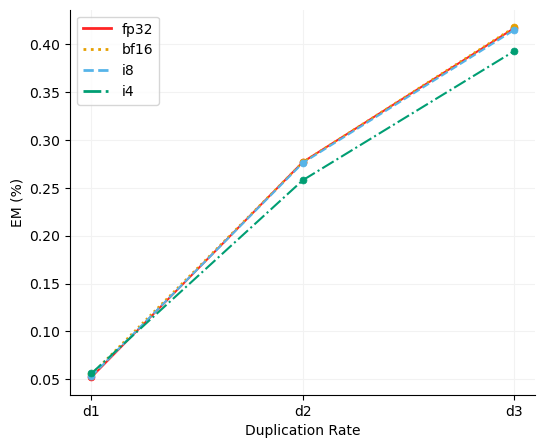

In [13]:
from matplotlib.lines import Line2D
from cycler import cycler

legend_elements = [Line2D([0], [0], lw=2, label='fp32', color='#FF2525', linestyle='-'),
                    Line2D([0], [0], lw=2, label='bf16', color='#E69F00', linestyle=':'),
                   Line2D([0], [0], lw=2, label='i8', color='#56B4E9', linestyle='--'),
                   Line2D([0], [0], lw=2, label='i4', color='#009E73', linestyle='-.')]


#plt.rc("axes", prop_cycle=line_cycler)
fig, ax = plt.subplots(figsize=(6, 5))

# Define colors and linestyles to match legend
labels = ['fp32', 'bf16', 'i8', 'i4']
colors = ['#FF2525', '#E69F00', '#56B4E9', '#009E73']
linestyles = ['-', ':', '--', '-.']
markers = ['o', 'o', 'o', 'o']

for i, label in enumerate(labels):
    # Line
    ax.plot(df_dedup_mem_plot.loc[["d1", "d2", "d3"]].index, df_dedup_mem_plot.loc[["d1", "d2", "d3"]][label],
            label=label,
            color=colors[i], linestyle=linestyles[i], marker=markers[i],
            markeredgewidth=0.5, markersize=5)

# Hide the all but the bottom spines (axis lines)
ax.spines["right"].set_visible(False)
#ax.spines["left"].set_visible(False)
ax.spines["top"].set_visible(False)

#ax.set_title('Data extraction attack through epochs')

ax.set_xlabel('Duplication Rate')
ax.set_ylabel('EM (%)')
plt.legend(frameon=True, handles=legend_elements)
plt.grid(axis='both', color='0.95', linestyle='-')



plt.show()
fig.savefig('./quant_attack_mem_dedup.pdf', format='pdf')

# Attack mem plen

In [14]:
expath = '../attack_mem_plen'
# results dataset
df = pd.read_parquet(os.path.join(expath,'attack_mem_plen.parquet'))

df_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_mem_plen/attack_mem_plen.parquet"))

merged_df = pd.merge(df, df_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')


## fp32

In [15]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'15b_{eps[1]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

plen_fp32_absolute = pd.DataFrame(mean_data, index=plens)
plen_fp32_absolute

,em,bleu,meteor,rougeL
p100,0.609,77.449415,0.801306,0.796559
p150,0.729,80.566627,0.854995,0.825766
p200,0.817,82.902077,0.878727,0.843539
p250,0.888,86.814412,0.912949,0.876072


In [16]:
# With the baseline

# compute the baselines
mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'15b_{eps[0]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

plen_fp32_ep0 = pd.DataFrame(mean_data, index=plens)
plen_fp32_baseline = plen_fp32_absolute.subtract(plen_fp32_ep0)
plen_fp32_baseline

,em,bleu,meteor,rougeL
p100,0.310,19.874890,0.170796,0.171847
p150,0.372,21.684561,0.204705,0.191712
p200,0.441,23.207238,0.209227,0.198899
p250,0.474,24.393655,0.202508,0.200509


## bf16

In [17]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'bf16_{eps[1]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

plen_bf16_absolute = pd.DataFrame(mean_data, index=plens)
plen_bf16_absolute

,em,bleu,meteor,rougeL
p100,0.610,77.305064,0.800632,0.795634
p150,0.729,80.629459,0.855073,0.826593
p200,0.818,83.010660,0.880203,0.844557
p250,0.886,86.838099,0.913214,0.876288


In [18]:
# With the baseline

# compute the baselines
mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'bf16_{eps[0]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

plen_bf16_ep0 = pd.DataFrame(mean_data, index=plens)
plen_bf16_baseline = plen_bf16_absolute.subtract(plen_bf16_ep0)
plen_bf16_baseline

,em,bleu,meteor,rougeL
p100,0.308,19.690140,0.171695,0.171181
p150,0.372,21.488027,0.204151,0.190602
p200,0.446,23.179070,0.214312,0.199980
p250,0.473,24.384591,0.201536,0.200508


§## i8

In [19]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'i8_{eps[1]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

plen_i8_absolute = pd.DataFrame(mean_data, index=plens)
plen_i8_absolute

,em,bleu,meteor,rougeL
p100,0.610,77.380866,0.801665,0.796619
p150,0.730,80.759182,0.854828,0.828089
p200,0.815,82.999878,0.880070,0.844494
p250,0.887,86.988900,0.914653,0.877091


In [20]:
# With the baseline

# compute the baselines
mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'i8_{eps[0]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

plen_i8_ep0 = pd.DataFrame(mean_data, index=plens)
plen_i8_baseline = plen_i8_absolute.subtract(plen_i8_ep0)
plen_i8_baseline

,em,bleu,meteor,rougeL
p100,0.313,20.259575,0.173198,0.176254
p150,0.375,22.102467,0.207859,0.196809
p200,0.447,23.720824,0.216369,0.203748
p250,0.469,24.146236,0.193217,0.195693


## i4

In [21]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'i4_{eps[1]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

plen_i4_absolute = pd.DataFrame(mean_data, index=plens)
plen_i4_absolute

,em,bleu,meteor,rougeL
p100,0.583,76.788414,0.795136,0.790262
p150,0.699,79.905429,0.839854,0.819446
p200,0.770,82.670905,0.870237,0.841684
p250,0.863,86.536426,0.907042,0.872620


In [22]:
# With the baseline

# compute the baselines
mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'i4_{eps[0]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

plen_i4_ep0 = pd.DataFrame(mean_data, index=plens)
plen_i4_baseline = plen_i4_absolute.subtract(plen_i4_ep0)
plen_i4_baseline

,em,bleu,meteor,rougeL
p100,0.369,26.046929,0.219355,0.219388
p150,0.451,28.210575,0.249759,0.240650
p200,0.491,30.112915,0.273353,0.253284
p250,0.573,31.325953,0.263943,0.253319


## Plots

In [23]:
df_plen_baseline = pd.DataFrame({'fp32': plen_fp32_baseline['em'],
                            'bf16': plen_bf16_baseline['em'],
                            'int8': plen_i8_baseline['em'],
                            'int4': plen_i4_baseline['em']
                            })
df_plen_baseline

,fp32,bf16,int8,int4
p100,0.310,0.308,0.313,0.369
p150,0.372,0.372,0.375,0.451
p200,0.441,0.446,0.447,0.491
p250,0.474,0.473,0.469,0.573


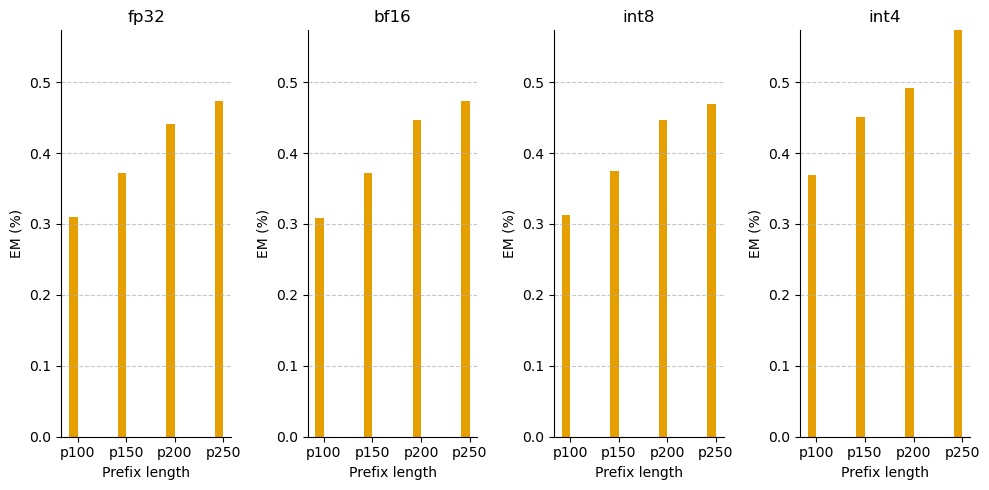

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(10, 5))  # Increased figure width
axes = axes.flatten()


# Number of bars (prefix lengths)
num_bars = len(df_plen_baseline.index)
bar_width = 0.35

# Define a color palette
labels = ['fp32', 'bf16', 'int8', 'int4']
max_value = max(df_plen_baseline.max().max(), df_plen_baseline.max().max())

# Define positions for the bars
bar_positions = np.arange(num_bars)  # x positions for bars

for i, label in enumerate(labels):
    ax = axes[i]

    # Define width for each group
    width = bar_width / 2  # Since there are two groups for each label (ptrain and ftune)

    # Positions for the bars in this group
    positions_ep0 = bar_positions - width / 2  # center align ptrain bars
    # positions_ep3 = bar_positions + width / 2  # center align ftune bars

    ax.bar(positions_ep0, df_plen_baseline[label], width, label='Base', color='#E69F00')
    #ax.bar(positions_ep3, df_plen_ep3[label], width, label='Fine-Tuned', color='#90C4FF')

    # Hide all but the bottom spines (axis lines)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    ax.set_xlabel('Prefix length')
    ax.set_ylabel('EM (%)')
    ax.set_title(f'{label}')

    #ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

    # Set the same y-axis limit
    ax.set_ylim(0, max_value)

    # Set x-ticks to the center of the bars
    ax.set_xticks(bar_positions)
    ax.set_xticklabels(df_plen_baseline.index)

    # Optional grid
    ax.grid(axis='y', linestyle='--', alpha=0.7)

#plt.legend(bbox_to_anchor=(1, 1))
#plt.legend(loc='upper left', bbox_to_anchor=(-2.4, 1.3), ncol=2)
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2)
plt.tight_layout()
plt.show()
fig.savefig('./quant_attack_mem_plen.pdf', format='pdf')

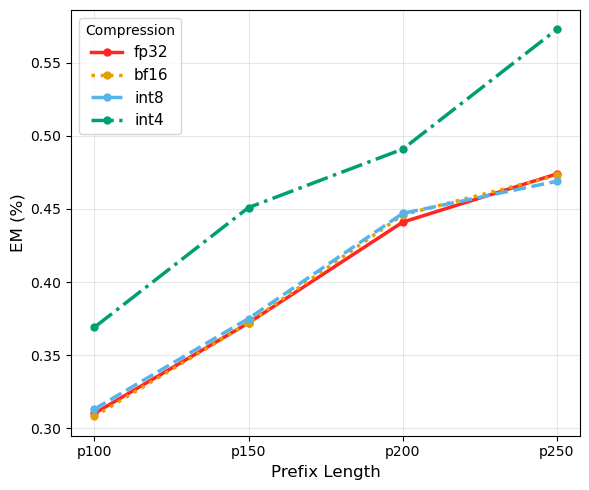

In [25]:
# Create a single figure and axis
fig, ax = plt.subplots(figsize=(6, 5))

prefix_lengths = ['p100', 'p150', 'p200', 'p250']
colors = ['#FF2525', '#E69F00', '#56B4E9', '#009E73']
linestyles = ['-', ':', '--', '-.']
markers = ['o', 'o', 'o', 'o']

# Plot on the created axis (ax), not plt
for i, (compression, color, linestyle, marker) in enumerate(zip(df_plen_baseline.columns, colors, linestyles, markers)):
    ax.plot(range(len(prefix_lengths)), df_plen_baseline[compression],
            marker=marker, linewidth=2.5, markersize=5,
            color=color, label=compression, linestyle=linestyle)

# Use ax methods instead of plt methods
ax.set_xlabel('Prefix Length', fontsize=12)
ax.set_ylabel('EM (%)', fontsize=12)
# ax.set_title('Memorization Increases with Prefix Length and Compression', fontsize=14, pad=20)
ax.set_xticks(range(len(prefix_lengths)))
ax.set_xticklabels(prefix_lengths)
ax.legend(title='Compression', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig('./quant_attack_mem_plen_dif1.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


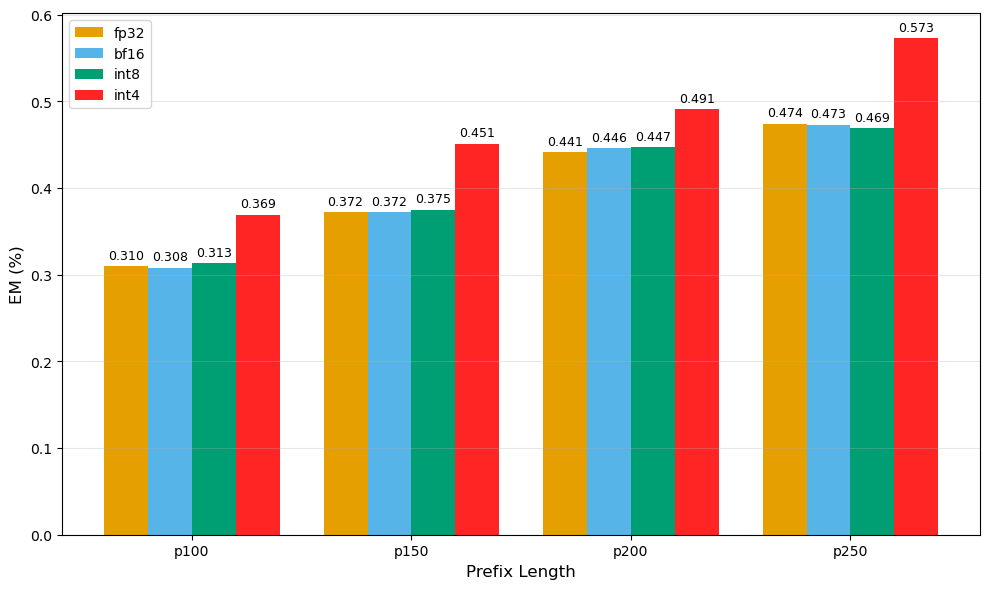

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the color palette for 4 different colors
colors = ['#E69F00', '#56B4E9', '#009E73', '#FF2525']

# Create the barplot
fig, ax = plt.subplots(figsize=(10, 6))

# Use prefix length data instead of categories
prefix_data = df_plen_baseline
x_plen = np.arange(len(prefix_data.index))  # p100, p150, p200, p250
width = 0.2

# Create bars for each precision setting
bars1 = ax.bar(x_plen - 1.5*width, prefix_data['fp32'], width, label='fp32', color=colors[0])
bars2 = ax.bar(x_plen - 0.5*width, prefix_data['bf16'], width, label='bf16', color=colors[1])
bars3 = ax.bar(x_plen + 0.5*width, prefix_data['int8'], width, label='int8', color=colors[2])
bars4 = ax.bar(x_plen + 1.5*width, prefix_data['int4'], width, label='int4', color=colors[3])

# Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

add_value_labels(bars1)
add_value_labels(bars2)
add_value_labels(bars3)
add_value_labels(bars4)

# Customize the plot
ax.set_xlabel('Prefix Length', fontsize=12)
ax.set_ylabel('EM (%)', fontsize=12)
# ax.set_title('Memorization by Prefix Length and Precision Setting')
ax.set_xticks(x_plen)
ax.set_xticklabels(prefix_data.index)  # p100, p150, p200, p250
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Adjust layout and show
plt.tight_layout()
plt.savefig('./quant_plen_bar.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

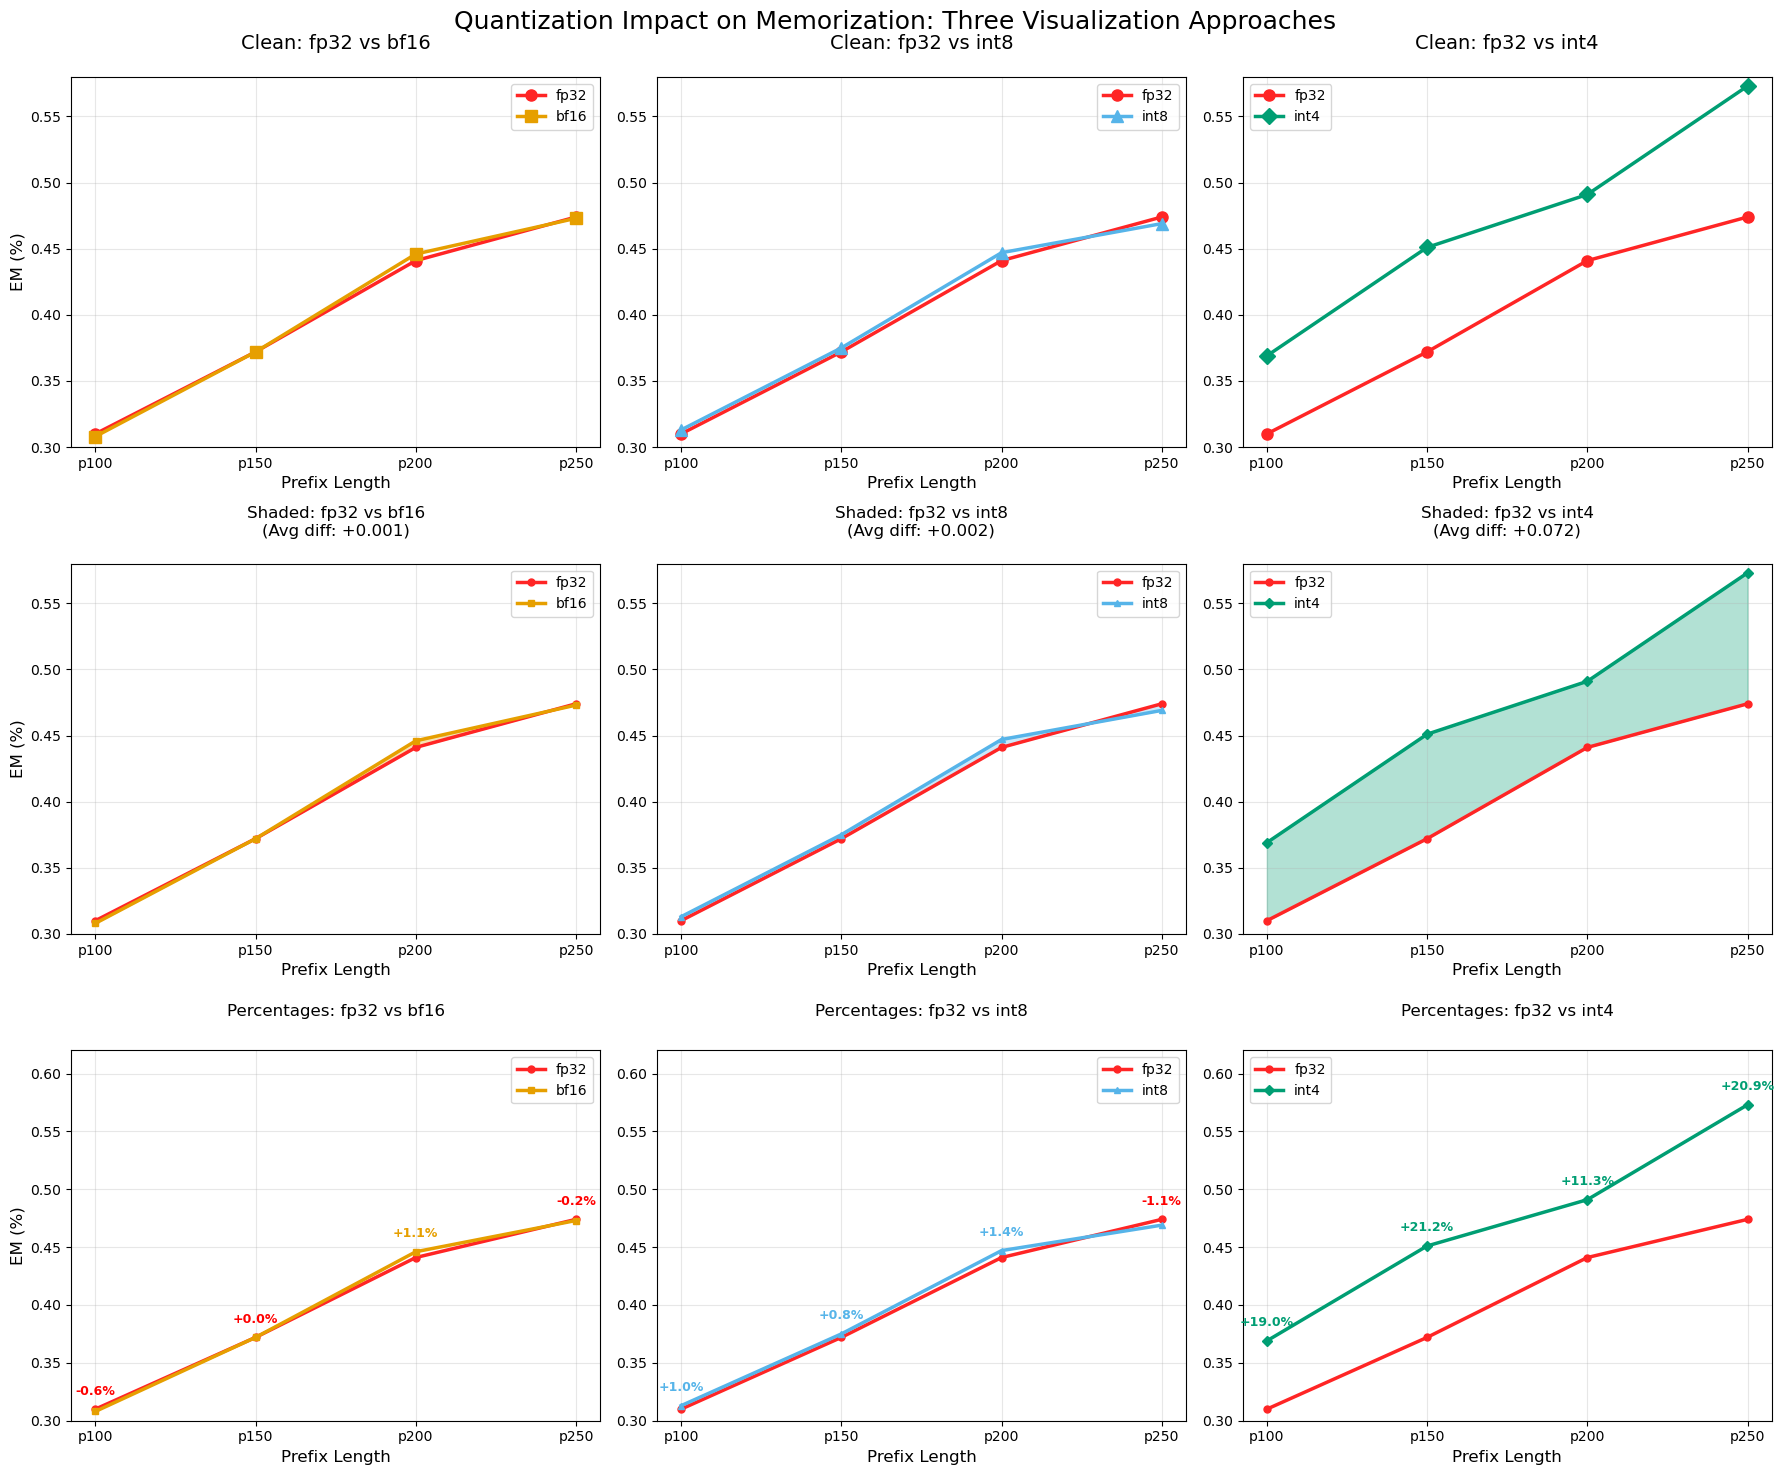

In [30]:
prefix_lengths = ['p100', 'p150', 'p200', 'p250']

# Create a large figure with 3 rows and 3 columns (9 subplots total)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# Colors and markers
fp32_color = '#FF2525'
comparison_colors = ['#E69F00', '#56B4E9', '#009E73']
fp32_marker = 'o'
comparison_markers = ['s', '^', 'D']

# Comparison models
comparison_models = ['bf16', 'int8', 'int4']

# VERSION 1: Clean comparison (Row 0)
for i, (model, color, marker) in enumerate(zip(comparison_models, comparison_colors, comparison_markers)):
    ax = axes[0, i]

    # Plot fp32 baseline
    ax.plot(range(len(prefix_lengths)), df_plen_baseline['fp32'],
            marker=fp32_marker, linewidth=2.5, markersize=8,
            color=fp32_color, label='fp32', linestyle='-')

    # Plot comparison model
    ax.plot(range(len(prefix_lengths)), df_plen_baseline[model],
            marker=marker, linewidth=2.5, markersize=8,
            color=color, label=model, linestyle='-')

    # Formatting
    ax.set_xlabel('Prefix Length', fontsize=12)
    if i == 0:  # Only leftmost plot gets y-label
        ax.set_ylabel('EM (%)', fontsize=12)

    ax.set_title(f'Clean: fp32 vs {model}', fontsize=14, pad=20)
    ax.set_xticks(range(len(prefix_lengths)))
    ax.set_xticklabels(prefix_lengths)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.3, 0.58)

# VERSION 2: With difference shading (Row 1)
for i, (model, color, marker) in enumerate(zip(comparison_models, comparison_colors, comparison_markers)):
    ax = axes[1, i]
    x_vals = range(len(prefix_lengths))
    fp32_vals = df_plen_baseline['fp32'].values
    model_vals = df_plen_baseline[model].values

    # Plot lines
    ax.plot(x_vals, fp32_vals,
            marker=fp32_marker, linewidth=2.5, markersize=5,
            color=fp32_color, label='fp32', linestyle='-', zorder=3)

    ax.plot(x_vals, model_vals,
            marker=marker, linewidth=2.5, markersize=5,
            color=color, label=model, linestyle='-', zorder=3)

    # Fill area between lines to show difference
    ax.fill_between(x_vals, fp32_vals, model_vals,
                    alpha=0.3, color=color if model_vals.mean() > fp32_vals.mean() else 'red')

    # Formatting
    ax.set_xlabel('Prefix Length', fontsize=12)
    if i == 0:  # Only leftmost plot gets y-label
        ax.set_ylabel('EM (%)', fontsize=12)

    # Calculate average difference for title
    avg_diff = (model_vals - fp32_vals).mean()
    ax.set_title(f'Shaded: fp32 vs {model}\n(Avg diff: {avg_diff:+.3f})', fontsize=12, pad=20)

    ax.set_xticks(range(len(prefix_lengths)))
    ax.set_xticklabels(prefix_lengths)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.3, 0.58)

# VERSION 3: With improvement percentages (Row 2)
for i, (model, color, marker) in enumerate(zip(comparison_models, comparison_colors, comparison_markers)):
    ax = axes[2, i]
    x_vals = range(len(prefix_lengths))
    fp32_vals = df_plen_baseline['fp32'].values
    model_vals = df_plen_baseline[model].values

    # Plot lines
    ax.plot(x_vals, fp32_vals,
            marker=fp32_marker, linewidth=2.5, markersize=5,
            color=fp32_color, label='fp32', linestyle='-')

    ax.plot(x_vals, model_vals,
            marker=marker, linewidth=2.5, markersize=5,
            color=color, label=model, linestyle='-')

    # Add percentage difference annotations
    for j, (x, fp32_val, model_val) in enumerate(zip(x_vals, fp32_vals, model_vals)):
        pct_diff = ((model_val - fp32_val) / fp32_val) * 100
        # Position annotation above the higher line
        y_pos = max(fp32_val, model_val) + 0.01
        ax.annotate(f'{pct_diff:+.1f}%',
                   xy=(x, y_pos), ha='center', va='bottom',
                   fontsize=9, fontweight='bold',
                   color=color if pct_diff > 0 else 'red')

    # Formatting
    ax.set_xlabel('Prefix Length', fontsize=12)
    if i == 0:
        ax.set_ylabel('EM (%)', fontsize=12)

    ax.set_title(f'Percentages: fp32 vs {model}', fontsize=12, pad=25)
    ax.set_xticks(range(len(prefix_lengths)))
    ax.set_xticklabels(prefix_lengths)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.3, 0.62)

# Add overall title
fig.suptitle('Quantization Impact on Memorization: Three Visualization Approaches',
             fontsize=18, y=0.98)

plt.tight_layout()
fig.savefig('./quant_attack_mem_plen_combined.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()

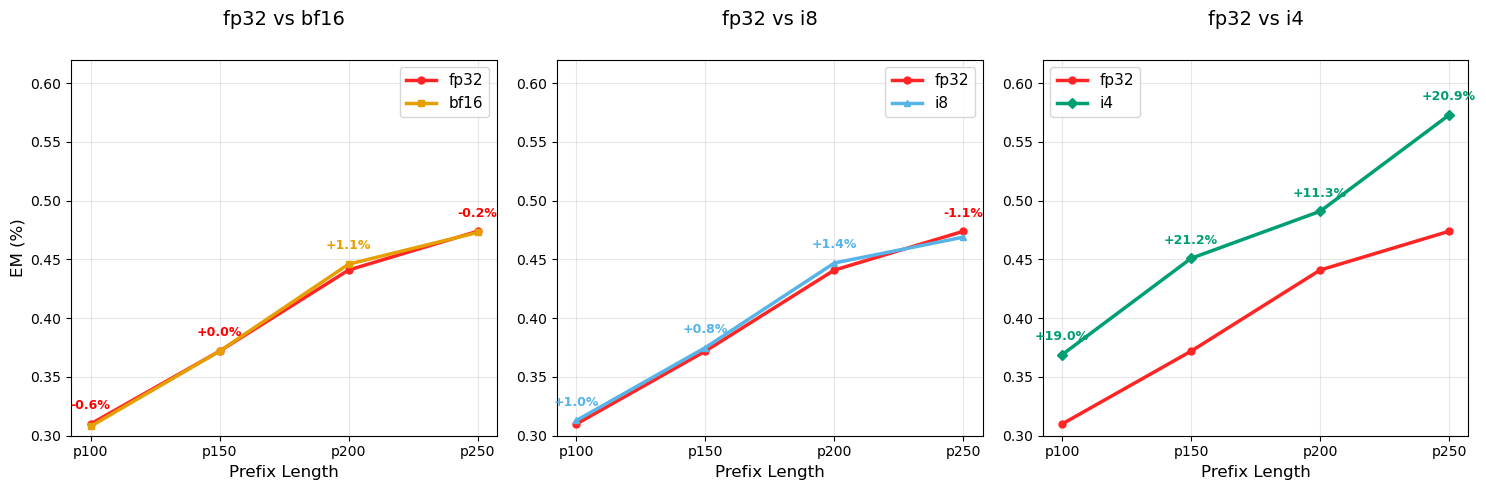

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (ax, model, color, marker) in enumerate(zip(axes, comparison_models, comparison_colors, comparison_markers)):
    x_vals = range(len(prefix_lengths))
    fp32_vals = df_plen_baseline['fp32'].values
    model_vals = df_plen_baseline[model].values

    # Plot lines
    ax.plot(x_vals, fp32_vals,
            marker=fp32_marker, linewidth=2.5, markersize=5,
            color=fp32_color, label='fp32', linestyle='-')

    ax.plot(x_vals, model_vals,
            marker=marker, linewidth=2.5, markersize=5,
            color=color, label=model, linestyle='-')

    # Add percentage difference annotations
    for j, (x, fp32_val, model_val) in enumerate(zip(x_vals, fp32_vals, model_vals)):
        pct_diff = ((model_val - fp32_val) / fp32_val) * 100
        # Position annotation above the higher line
        y_pos = max(fp32_val, model_val) + 0.01
        ax.annotate(f'{pct_diff:+.1f}%',
                   xy=(x, y_pos), ha='center', va='bottom',
                   fontsize=9, fontweight='bold',
                   color=color if pct_diff > 0 else 'red')

    # Formatting
    ax.set_xlabel('Prefix Length', fontsize=12)
    if i == 0:
        ax.set_ylabel('EM (%)', fontsize=12)

    ax.set_title(f'fp32 vs {model}', fontsize=14, pad=25)
    ax.set_xticks(range(len(prefix_lengths)))
    ax.set_xticklabels(prefix_lengths)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    # Set same y-limits with extra space for annotations
    ax.set_ylim(0.3, 0.62)

plt.tight_layout()
plt.show()
fig.savefig('./quant_attack_mem_plen_dif3.pdf', format='pdf')
